In [1]:
import pandas as pd
import numpy as np
import warnings 
import re
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

### Data Loading

In [25]:
bb=pd.read_csv(r"C:\Users\veera\python im\EDA\metro\bigbasket_main.csv")
b=pd.read_csv(r"C:\Users\veera\python im\EDA\metro\blinkit_main.csv")

In [26]:
bb

,Unnamed: 0,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Late_Night_Charges,Delivery_Charges(Handelling+Delivery+Late_Night_Charge),Delivery_Charges(Handelling+Delivery+Late_Night_Charges)
0,0,Heritage Fresh Paneer,Paneer,Out of Stock,Out of Stock,Out of Stock,Out of Stock,Out of Stock,03-03-2026,23:34:32,KPHB colony,0.0,Night,NaN,Clear,No,11.0,NaN,NaN
1,1,Heritage Nourish High Protein Paneer,Paneer,150,125,17% OFF,18 MINS,240 g - Pouch,03-03-2026,23:34:43,KPHB colony,37.0,Night,NaN,Clear,No,11.0,NaN,NaN
2,2,Heritage Daily Health Toned Milk,Milk,32,32,NaN,20 MINS,500 ml - Pouch,03-03-2026,23:34:54,KPHB colony,37.0,Night,NaN,Clear,No,11.0,NaN,NaN
3,3,Heritage Full Cream Milk,Milk,42,40,5% OFF,18 MINS,500 ml,03-03-2026,23:35:05,KPHB colony,37.0,Night,NaN,Clear,No,11.0,NaN,NaN
4,4,Arokya Full Cream Milk,Milk,42,40,5% OFF,19 MINS,500 ml,03-03-2026,23:35:17,KPHB colony,37.0,Night,NaN,Clear,No,11.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,35,fresho! Nagpur Orange,Fruit,129,79,39% OFF,8 MINS,1 kg - (Approx. 6 - 8 pcs),06-03-2026,09:09:26,Beeramguda,21.0,Morning,NaN,Clear,No,NaN,NaN,21.0
956,36,fresho! Mini Orange Imported,Fruit,144,115.2,20% OFF,8 MINS,500 g,06-03-2026,09:09:36,Beeramguda,21.0,Morning,NaN,Clear,No,NaN,NaN,21.0
957,37,fresho! Lemon,Vegetable,54,38.5,29% OFF,8 MINS,250 g,06-03-2026,09:09:47,Beeramguda,21.0,Morning,NaN,Clear,No,NaN,NaN,21.0
958,38,"fresho! Chilli - Green Long, Medium",Vegetable,17,11,35% OFF,8 MINS,100 g,06-03-2026,09:09:57,Beeramguda,21.0,Morning,NaN,Clear,No,NaN,NaN,21.0


In [4]:
bb.shape

(960, 19)

In [5]:
b.shape

(1160, 16)

## Changing columns

In [8]:
b.columns

Index(['Unnamed: 0', 'name', 'Category', 'mrp', 'selling_price',
       'offer_percentage', 'delivery_time', 'quantity', 'scrape_date',
       'scrape_time', 'location', 'Delivery_Charges(Handelling+Delivery)',
       'Period', 'Surge', 'Climate', 'Surge_charges'],
      dtype='object')

In [9]:
bb.columns

Index(['Unnamed: 0', 'name', 'Category', 'mrp', 'selling_price',
       'offer_percentage', 'delivery_time', 'quantity', 'scrape_date',
       'scrape_time', 'location', 'Delivery_Charges(Handelling+Delivery)',
       'Period', 'Surge', 'Climate', 'Surge_charges', 'Late_Night_Charges',
       'Delivery_Charges(Handelling+Delivery+Late_Night_Charge)',
       'Delivery_Charges(Handelling+Delivery+Late_Night_Charges)'],
      dtype='object')

In [6]:
bb.drop(['Unnamed: 0','Delivery_Charges(Handelling+Delivery+Late_Night_Charges)','Late_Night_Charges','Delivery_Charges(Handelling+Delivery+Late_Night_Charge)'],axis=1,inplace=True)

In [7]:
(bb.columns)

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time', 'quantity', 'scrape_date', 'scrape_time', 'location',
       'Delivery_Charges(Handelling+Delivery)', 'Period', 'Surge', 'Climate',
       'Surge_charges'],
      dtype='object')

In [8]:
b.drop('Unnamed: 0',inplace=True,axis=1)

In [9]:
b.columns

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time', 'quantity', 'scrape_date', 'scrape_time', 'location',
       'Delivery_Charges(Handelling+Delivery)', 'Period', 'Surge', 'Climate',
       'Surge_charges'],
      dtype='object')

In [10]:
b.shape

(1160, 15)

In [11]:
bb.shape

(960, 15)

In [12]:
b["Platform"]="Blinkit"


In [13]:
bb["Platform"]="BigBasket"

In [14]:
b.shape

(1160, 16)

In [15]:
bb.shape


(960, 16)

In [16]:
df=pd.concat([b,bb],ignore_index=True)

In [17]:
df.shape

(2120, 16)

In [22]:
df.head()

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform
0,Heritage Fresh Paneer,Paneer,115.0,101,12% OFF,13 MINS,200 g,2026-03-03,12:56:15,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
1,Heritage Nourish+ High Protein Paneer,Paneer,150.0,125,16% OFF,13 MINS,240 g,2026-03-03,12:56:29,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
2,Heritage Daily Health Toned Milk,Milk,32,32,NaN,13 MINS,500 ml,2026-03-03,12:56:44,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
3,Heritage Full Cream Milk,Milk,42,42,NaN,13 MINS,500 ml,2026-03-03,12:56:59,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
4,Arokya Full Cream Milk,Milk,42,42,NaN,13 MINS,500 ml,2026-03-03,12:57:15,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2120 entries, 0 to 2119
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   name                                   2120 non-null   object 
 1   Category                               2120 non-null   object 
 2   mrp                                    2119 non-null   object 
 3   selling_price                          2119 non-null   object 
 4   offer_percentage                       1510 non-null   object 
 5   delivery_time                          2106 non-null   object 
 6   quantity                               2085 non-null   object 
 7   scrape_date                            2120 non-null   object 
 8   scrape_time                            2120 non-null   object 
 9   location                               2120 non-null   object 
 10  Delivery_Charges(Handelling+Delivery)  2100 non-null   float64
 11  Peri

## Duplicates Handeling

In [98]:
len(df[df.duplicated()])

1

In [99]:
df[df.duplicated()]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform
901,Premier Mutton Curry Cut,Meat,799,485,39% OFF,13 MINS,480 g,04-03-2026,08:06:35,Beeramguda,27.0,Morning,NaN,Clear,No,Blinkit


In [100]:
df[900:905]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform
900,Premier Mutton Curry Cut,Meat,799,485,39% OFF,13 MINS,480 g,04-03-2026,08:06:35,Beeramguda,27.0,Morning,NaN,Clear,No,Blinkit
901,Premier Mutton Curry Cut,Meat,799,485,39% OFF,13 MINS,480 g,04-03-2026,08:06:35,Beeramguda,27.0,Morning,NaN,Clear,No,Blinkit
902,Oraganically Grown Potato,Vegetable,40,35,12% OFF,17 MINS,250 g,04-03-2026,08:07:04,Beeramguda,27.0,Morning,NaN,Clear,No,Blinkit
903,Orange Carrot,Vegetable,24,19,20% OFF,17 MINS,500 g,04-03-2026,08:07:20,Beeramguda,27.0,Morning,NaN,Clear,No,Blinkit
904,Beetroot,Other,Out of Stock,Out of Stock,Out of Stock,Out of Stock,Out of Stock,04-03-2026,08:07:36,Beeramguda,0.0,Morning,NaN,Clear,No,Blinkit


In [101]:
df.drop_duplicates(inplace=True)


## Missing Value Treatement 

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2119 entries, 0 to 2119
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   name                                   2119 non-null   object 
 1   Category                               2119 non-null   object 
 2   mrp                                    2118 non-null   object 
 3   selling_price                          2118 non-null   object 
 4   offer_percentage                       1509 non-null   object 
 5   delivery_time                          2105 non-null   object 
 6   quantity                               2084 non-null   object 
 7   scrape_date                            2119 non-null   object 
 8   scrape_time                            2119 non-null   object 
 9   location                               2119 non-null   object 
 10  Delivery_Charges(Handelling+Delivery)  2099 non-null   float64
 11  Period   

In [102]:
df.loc[(df["mrp"].isna())|( df["mrp"]=="Out of Stock"),"mrp"]=0.0

In [ ]:
# df["mrp"].fillna(0,inplace=True) 

In [103]:
df[(df["mrp"].isna()) |( df["mrp"]=="Out of Stock")]["mrp"]


Series([], Name: mrp, dtype: object)

In [104]:
df["selling_price"].isna().sum()

np.int64(1)

In [105]:
df["selling_price"].fillna(0,inplace=True)

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\614920863.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["selling_price"].fillna(0,inplace=True)


In [106]:
df["selling_price"].isna().sum()

np.int64(0)

In [107]:
df["selling_price"].isna().sum()

np.int64(0)

In [108]:
df['offer_percentage'].fillna(0,inplace=True)

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\3013686165.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['offer_percentage'].fillna(0,inplace=True)


In [109]:
df['offer_percentage'].isna().sum()

np.int64(0)

In [116]:
df.dropna(subset=["delivery_time"],axis=0,inplace=True)

In [117]:
df["delivery_time"].isna().sum()

np.int64(0)

In [72]:
df.columns

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time', 'quantity', 'scrape_date', 'scrape_time', 'location',
       'Delivery_Charges(Handelling+Delivery)', 'Period', 'Surge', 'Climate',
       'Surge_charges', 'Platform'],
      dtype='object')

In [119]:
df[df["quantity"].isna()]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform
33,Banana (Aratipandu),Fruit,33.0,27,18% OFF,13 MINS,NaN,2026-03-03,13:05:22,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
73,Banana (Aratipandu),Fruit,32.0,27,15% OFF,15 MINS,NaN,2026-03-03,19:03:48,KPHB colony,36.0,Evening,NaN,clear,No,Blinkit
113,Banana (Aratipandu),Fruit,31.0,27,12% OFF,16 MINS,NaN,2026-03-03,22:53:19,KPHB colony,36.0,Night,NaN,clear,No,Blinkit
153,Banana (Aratipandu),Fruit,31.0,27,12% OFF,17 MINS,NaN,2026-03-04,09:38:46,KPHB colony,36.0,Morning,NaN,Clear,No,Blinkit
193,Banana (Aratipandu),Fruit,33.0,27,18% OFF,15 MINS,NaN,2026-03-04,15:42:39,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
233,Banana (Aratipandu),Fruit,34.0,27,20% OFF,14 MINS,NaN,2026-03-05,15:36:17,KPHB colony,36.0,Afternoon,NaN,sunny,No,Blinkit
273,Banana (Aratipandu),Fruit,31.0,27,12% OFF,19 MINS,NaN,2026-03-05,17:18:09,KPHB colony,36.0,Evening,NaN,clear,No,Blinkit
313,Banana (Aratipandu),Fruit,29.0,23,20% OFF,13 MINS,NaN,2026-03-06,15:15:08,KPHB colony,35.0,Afternoon,NaN,sunny,No,Blinkit
353,Banana (Aratipandu),Fruit,31.0,27,12% OFF,13 MINS,NaN,2026-03-04,23:28:51,KPHB colony,36.0,Night,NaN,clear,No,Blinkit
393,Banana (Aratipandu),Fruit,33.0,27,18% OFF,8 MINS,NaN,2026-03-03,12:00:08,Madhapur,36.0,Afternoon,NaN,Sunny,No,Blinkit


In [122]:
df.loc[(df["name"]=="Banana (Aratipandu)") & (df["quantity"].isna()),"quantity"]="3 pcs"

In [123]:
df[df["quantity"].isna()]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform
1394,fresho! Banana - Raw Green,Fruit,24,21.12,12% OFF,6 MINS,NaN,05-03-2026,17:32:31,KPHB colony,21.0,Evening,NaN,Clear,No,BigBasket
1474,fresho! Banana - Raw Green,Fruit,24.0,21.12,12% OFF,11 MINS,NaN,2026-03-06,12:32:18,Kondapur,21.0,Afternoon,NaN,Sunny,No,BigBasket
1794,fresho! Banana - Raw Green,Fruit,24.0,21.12,12% OFF,14 MINS,NaN,2026-03-06,14:59:24,Gachibowli,21.0,Afternoon,NaN,Sunny,No,BigBasket
1834,fresho! Banana - Raw Green,Fruit,24,21.12,12% OFF,13 MINS,NaN,03-03-2026,23:26:25,Beeramguda,35.0,Night,NaN,Clear,No,BigBasket
1874,fresho! Banana - Raw Green,Fruit,24.0,21.12,12% OFF,7 MINS,NaN,2026-03-04,08:45:53,Beeramguda,21.0,Morning,NaN,Clear,No,BigBasket
1914,fresho! Banana - Raw Green,Fruit,24.0,21.12,12% OFF,20 MINS,NaN,2026-03-04,14:53:01,Beeramguda,21.0,Afternoon,NaN,Clear,No,BigBasket
1994,fresho! Banana - Raw Green,Fruit,24,21.12,12% OFF,19 MINS,NaN,04-03-2026,23:06:14,Beeramguda,35.0,Night,NaN,Clear,No,BigBasket
2034,fresho! Banana - Raw Green,Fruit,24.0,21.12,12% OFF,9 MINS,NaN,2026-03-05,08:31:24,Beeramguda,21.0,Morning,NaN,Clear,No,BigBasket
2074,fresho! Banana - Raw Green,Fruit,24,21.12,12% OFF,9 MINS,NaN,05-03-2026,22:20:18,Beeramguda,35.0,Night,NaN,Clear,No,BigBasket
2114,fresho! Banana - Raw Green,Fruit,24,21.12,12% OFF,8 MINS,NaN,06-03-2026,09:09:16,Beeramguda,21.0,Morning,NaN,Clear,No,BigBasket


In [129]:
df.loc[(df["name"]=="fresho! Banana - Raw Green" )& (df["quantity"].isna()),"quantity"]="1 pcs"

In [131]:
df[df["quantity"].isna()]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Surge,Climate,Surge_charges,Platform


In [137]:
df.loc[df["Delivery_Charges(Handelling+Delivery)"].isna(),"Delivery_Charges(Handelling+Delivery)"]=0.0

In [140]:
df["Delivery_Charges(Handelling+Delivery)"].isna().sum()

np.int64(0)

In [147]:
df["Surge_charges"].fillna(0.0,inplace=True)

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\1798212072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Surge_charges"].fillna(0.0,inplace=True)


In [148]:
df.drop(["Surge"],inplace=True,axis=1)

In [143]:
df["Climate"].mode()

0    Clear
Name: Climate, dtype: object

In [144]:
df["Climate"].fillna(df["Climate"].mode()[0],inplace=True)

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\557543133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Climate"].fillna(df["Climate"].mode()[0],inplace=True)


In [146]:
df["Climate"].isna().sum()

np.int64(0)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2105 entries, 0 to 2119
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   name                                   2105 non-null   object 
 1   Category                               2105 non-null   object 
 2   mrp                                    2105 non-null   object 
 3   selling_price                          2105 non-null   object 
 4   offer_percentage                       2105 non-null   object 
 5   delivery_time                          2105 non-null   object 
 6   quantity                               2105 non-null   object 
 7   scrape_date                            2105 non-null   object 
 8   scrape_time                            2105 non-null   object 
 9   location                               2105 non-null   object 
 10  Delivery_Charges(Handelling+Delivery)  2105 non-null   float64
 11  Period   

In [150]:
df["Period"].mode()

0    Afternoon
Name: Period, dtype: object

In [151]:
df["Period"].fillna(df["Period"].mode()[0],inplace=True)


C:\Users\veera\AppData\Local\Temp\ipykernel_35188\1467908112.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Period"].fillna(df["Period"].mode()[0],inplace=True)


In [164]:
df.loc[df["selling_price"]=="Out of Stock","selling_price"]=0.0


In [165]:
df[df["selling_price"]=="Out of Stock"]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform


In [166]:
df[df["offer_percentage"]=="Out of Stock"]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform
7,Sids Farm Cow Milk,Milk,0,0.0,Out of Stock,Out of Stock,Out of Stock,2026-03-03,12:58:00,KPHB colony,0.0,Afternoon,sunny,No,Blinkit
12,FreshtoHome Chicken - Skinless Curry Cut,Chicken,0,0.0,Out of Stock,Out of Stock,Out of Stock,2026-03-03,12:59:25,KPHB colony,0.0,Afternoon,sunny,No,Blinkit
14,Super Cool Frozen Skinless Chicken Drumstickso...,Chicken,0,0.0,Out of Stock,Out of Stock,Out of Stock,2026-03-03,12:59:58,KPHB colony,0.0,Afternoon,sunny,No,Blinkit
15,Organically Grown Onion (Ulligadda),Vegetable,0,0.0,Out of Stock,Out of Stock,Out of Stock,2026-03-03,13:00:12,KPHB colony,0.0,Afternoon,sunny,No,Blinkit
17,Desi Tomato (Tamatar),Vegetable,0,0.0,Out of Stock,Out of Stock,Out of Stock,2026-03-03,13:00:44,KPHB colony,0.0,Afternoon,sunny,No,Blinkit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2070,"Farm Eggs-Medium, Brown",Eggs,0,0.0,Out of Stock,Out of Stock,Out of Stock,05-03-2026,22:19:34,Beeramguda,0.0,Night,Clear,No,BigBasket
2081,Heritage Nourish High Protein Paneer,Paneer,0,0.0,Out of Stock,Out of Stock,Out of Stock,06-03-2026,09:03:48,Beeramguda,0.0,Morning,Clear,No,BigBasket
2089,Amul Buffalo Milk,Milk,0,0.0,Out of Stock,Out of Stock,Out of Stock,06-03-2026,09:05:09,Beeramguda,0.0,Morning,Clear,No,BigBasket
2095,"fresho! Red Onion Skinned - Peeled, Small",Vegetable,0,0.0,Out of Stock,Out of Stock,Out of Stock,06-03-2026,09:06:08,Beeramguda,0.0,Morning,Clear,No,BigBasket


In [192]:
df.loc[df["offer_percentage"]=="Out of Stock","offer_percentage"]=0.0
df.loc[df["delivery_time"]=="Out of Stock","delivery_time"]=0.0
df.loc[df["quantity"]=="Out of Stock","quantity"]=0.0


In [193]:
df.loc[[36,156,196,236,316,396,782]].index
df.drop([36,156,196,236,316,396,782],axis=0,inplace=True)


,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform
0,Heritage Fresh Paneer,Paneer,115,101.0,12% OFF,13 MINS,200 g,2026-03-03,12:56:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
1,Heritage Nourish+ High Protein Paneer,Paneer,150,125.0,16% OFF,13 MINS,240 g,2026-03-03,12:56:29,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
2,Heritage Daily Health Toned Milk,Milk,32,32.0,0,13 MINS,500 ml,2026-03-03,12:56:44,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
3,Heritage Full Cream Milk,Milk,42,42.0,0,13 MINS,500 ml,2026-03-03,12:56:59,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
4,Arokya Full Cream Milk,Milk,42,42.0,0,13 MINS,500 ml,2026-03-03,12:57:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,fresho! Nagpur Orange,Fruit,129,79.0,39% OFF,8 MINS,1 kg - (Approx. 6 - 8 pcs),06-03-2026,09:09:26,Beeramguda,21.0,Morning,Clear,No,BigBasket
2116,fresho! Mini Orange Imported,Fruit,144,115.2,20% OFF,8 MINS,500 g,06-03-2026,09:09:36,Beeramguda,21.0,Morning,Clear,No,BigBasket
2117,fresho! Lemon,Vegetable,54,38.5,29% OFF,8 MINS,250 g,06-03-2026,09:09:47,Beeramguda,21.0,Morning,Clear,No,BigBasket
2118,"fresho! Chilli - Green Long, Medium",Vegetable,17,11.0,35% OFF,8 MINS,100 g,06-03-2026,09:09:57,Beeramguda,21.0,Morning,Clear,No,BigBasket


## Type Casting

In [159]:
df["mrp"]=df["mrp"].astype("float")

In [160]:
df["mrp"]=df["mrp"].astype("int")

In [162]:
df["mrp"].dtype

dtype('int64')

In [168]:
df["selling_price"]=df["selling_price"].astype("float")

In [169]:
df["selling_price"].dtype

dtype('float64')

In [173]:
df["offer_percentage"]

0       12% OFF
1       16% OFF
2             0
3             0
4             0
         ...   
2115    39% OFF
2116    20% OFF
2117    29% OFF
2118    35% OFF
2119    20% OFF
Name: offer_percentage, Length: 2105, dtype: object

In [210]:
x=[]
for i in df["offer_percentage"]:
    v=re.findall(r"(\d+).*| \d",str(i))
    x.append(v[0])
df["offer_percentage"]=x

In [240]:
df["offer_percentage"]=df["offer_percentage"].astype(int)

In [18]:
######################################################################
st=[]
for i in df["mrp"]:
    if i==0:
        st.append("false")
    else:
        st.append("true")
len(st)
df["Stock"]=st

bins = [0, 50, 100, 200, 300, 500, 1100]
labels = ['0-50', '51-100', '101-200', '201-300', '301-500', '500+']
df['sp_range'] = pd.cut(df['selling_price'], bins=bins, labels=labels, include_lowest=True)

bins = [0, 50, 100, 200, 300, 500, 1000]
labels = ['0-50', '51-100', '101-200', '201-300', '301-500', '500+']
df['mrp_range'] = pd.cut(df['mrp'], bins=bins, labels=labels)


In [238]:
df["quantity"].unique()

array(['200 g', '240 g', '500 ml', '200 ml', 0.0, '450 ml', '1 ltr',
       '500 g', '480 g', '6 pcs', '12 pcs', '225 g', '300 g', '3 pcs',
       '100 g', '400 g', '450 g', '1 kg', '30 pcs', '250 ml', '350 g',
       '4 pcs', '500ml', '7 to 11 pcs', '250 g', '1.8 kg', '250 g ',
       '240 g - Pouch', '500 ml - Pouch', '1 L', '200 g - Pouch',
       '450 g - Tray Pack', '500 g - (2-4 pcs)',
       '4 pcs - (Approx. 600 g -700 g)', '1 pc - (300 g - 450 g approx.)',
       '1 L - Carton', '1 L - Tetra Pak', '1 kg - (4-6 pcs)', '10 pcs',
       '4 pcs - (Approx .500 g - 650 g)', '1 kg - (Approx. 6 - 8 pcs)',
       '1 pc - (Approx. 500 g - 800 g)', '200 ml - Carton',
       '2 pcs - Approx. 260 g - 300 g', '1 pcs', '150 g',
       '450 ml - Pouch'], dtype=object)

In [233]:
df.loc[725,"quantity"]="500ml" 
df.loc[725,"offer_percentage"]=0.0
df.loc[547,"quantity"]="6 pcs"
df.loc[747,"quantity"]="6 pcs"
df.loc[732,"quantity"]="7 to 11 pcs"
df.loc[942,"quantity"]="250 g"
df.loc[1102,"quantity"]="250 g"


In [234]:
df[df["quantity"]=="Table White Eggs (6 pcs)"]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform


In [235]:
df[df["quantity"]=="Licious Chicken Curry Cut (Large - 7 to 11 Pcs)"]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform


In [236]:
df[df["quantity"]=="Organically Grown Sweet Potato - 250 g (Chilakada Dumpa)"]

,name,Category,mrp,selling_price,offer_percentage,delivery_time,quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2105 entries, 0 to 2119
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   name                                   2105 non-null   object 
 1   Category                               2105 non-null   object 
 2   mrp                                    2105 non-null   int64  
 3   selling_price                          2105 non-null   float64
 4   offer_percentage                       2105 non-null   int64  
 5   delivery_time                          2105 non-null   object 
 6   quantity                               2105 non-null   object 
 7   scrape_date                            2105 non-null   object 
 8   scrape_time                            2105 non-null   object 
 9   location                               2105 non-null   object 
 10  Delivery_Charges(Handelling+Delivery)  2105 non-null   float64
 11  Period   

In [246]:
d=[]
for i in df["delivery_time"]:
    z=re.findall(r"(\d+).*",str(i))
    d.append(z[0])
df["delivery_time"]=d

In [247]:
df["delivery_time"]=df["delivery_time"].astype("int")

In [250]:
df.rename(columns={"delivery_time":"delivery_time(MIN)"})

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform
0,Heritage Fresh Paneer,Paneer,115,101.0,12,13,200 g,2026-03-03,12:56:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
1,Heritage Nourish+ High Protein Paneer,Paneer,150,125.0,16,13,240 g,2026-03-03,12:56:29,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
2,Heritage Daily Health Toned Milk,Milk,32,32.0,0,13,500 ml,2026-03-03,12:56:44,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
3,Heritage Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:56:59,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
4,Arokya Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:57:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,fresho! Nagpur Orange,Fruit,129,79.0,39,8,1 kg - (Approx. 6 - 8 pcs),06-03-2026,09:09:26,Beeramguda,21.0,Morning,Clear,No,BigBasket
2116,fresho! Mini Orange Imported,Fruit,144,115.2,20,8,500 g,06-03-2026,09:09:36,Beeramguda,21.0,Morning,Clear,No,BigBasket
2117,fresho! Lemon,Vegetable,54,38.5,29,8,250 g,06-03-2026,09:09:47,Beeramguda,21.0,Morning,Clear,No,BigBasket
2118,"fresho! Chilli - Green Long, Medium",Vegetable,17,11.0,35,8,100 g,06-03-2026,09:09:57,Beeramguda,21.0,Morning,Clear,No,BigBasket


In [251]:
df

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform
0,Heritage Fresh Paneer,Paneer,115,101.0,12,13,200 g,2026-03-03,12:56:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
1,Heritage Nourish+ High Protein Paneer,Paneer,150,125.0,16,13,240 g,2026-03-03,12:56:29,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
2,Heritage Daily Health Toned Milk,Milk,32,32.0,0,13,500 ml,2026-03-03,12:56:44,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
3,Heritage Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:56:59,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
4,Arokya Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:57:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,fresho! Nagpur Orange,Fruit,129,79.0,39,8,1 kg - (Approx. 6 - 8 pcs),06-03-2026,09:09:26,Beeramguda,21.0,Morning,Clear,No,BigBasket
2116,fresho! Mini Orange Imported,Fruit,144,115.2,20,8,500 g,06-03-2026,09:09:36,Beeramguda,21.0,Morning,Clear,No,BigBasket
2117,fresho! Lemon,Vegetable,54,38.5,29,8,250 g,06-03-2026,09:09:47,Beeramguda,21.0,Morning,Clear,No,BigBasket
2118,"fresho! Chilli - Green Long, Medium",Vegetable,17,11.0,35,8,100 g,06-03-2026,09:09:57,Beeramguda,21.0,Morning,Clear,No,BigBasket


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2105 entries, 0 to 2119
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   name                                   2105 non-null   object 
 1   Category                               2105 non-null   object 
 2   mrp                                    2105 non-null   int64  
 3   selling_price                          2105 non-null   float64
 4   offer_percentage                       2105 non-null   int64  
 5   delivery_time(MIN)                     2105 non-null   int64  
 6   quantity                               2105 non-null   object 
 7   scrape_date                            2105 non-null   object 
 8   scrape_time                            2105 non-null   object 
 9   location                               2105 non-null   object 
 10  Delivery_Charges(Handelling+Delivery)  2105 non-null   float64
 11  Period   

In [369]:
df.loc[(df["name"]=="Amul Gold Homogenised Standardised") & (df["Category"]=="Other"),"Category"]="Milk"

In [357]:
df.loc[(df["name"]=="Beetroot") & (df["Category"]=="Other"),"Category"]="Vegetable"

In [370]:
df[(df["name"]=="Beetroot") & (df["Category"]=="Other")]

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform,mrp_range,sp_range


In [374]:
df[(df["name"]=="Amul Gold Homogenised Standardised") &(df["Category"]=="Other")]

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform,mrp_range,sp_range


In [410]:
# df.loc[834,"Category"]="Milk" 
df.loc[831]

name                                     Sids Farm Buffalo A2 Milk
Category                                                      Milk
mrp                                                             63
selling_price                                                 63.0
offer_percentage                                                 0
delivery_time(MIN)                                               7
quantity                                                    500 ml
scrape_date                                             03-03-2026
scrape_time                                               22:29:31
location                                                Beeramguda
Delivery_Charges(Handelling+Delivery)                         27.0
Period                                                       Night
Climate                                                      Clear
Surge_charges                                                   No
Platform                                                   Bli

In [411]:
df["Category"].unique()
df[df["Category"]=='Other']

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform,mrp_range,sp_range
36,N\A,Other,70,57.0,18,13,200 g,2026-03-03,13:06:05,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,51-100,51-100
156,N\A,Other,71,57.0,19,17,200 g,2026-03-04,09:39:28,KPHB colony,36.0,Morning,Clear,No,Blinkit,51-100,51-100
196,N\A,Other,73,57.0,21,15,200 g,2026-03-04,15:43:20,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,51-100,51-100
236,N\A,Other,66,57.0,13,14,200 g,2026-03-05,15:36:58,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,51-100,51-100
316,N\A,Other,66,57.0,13,13,200 g,2026-03-06,15:15:45,KPHB colony,35.0,Afternoon,sunny,No,Blinkit,51-100,51-100
396,N\A,Other,68,57.0,16,8,200 g,2026-03-03,12:00:46,Madhapur,36.0,Afternoon,Sunny,No,Blinkit,51-100,51-100
782,N\A,Other,68,57.0,16,9,200 g,03-03-2026,12:52:41,Beeramguda,27.0,Afternoon,Sunny,No,Blinkit,51-100,51-100


In [422]:
df.loc[[36,156,196,236,316,396,782]].index
df.drop([36,156,196,236,316,396,782],axis=0,inplace=True)


In [484]:
st=[]
for i in df["mrp"]:
    if i==0:
        st.append("false")
    else:
        st.append("true")
len(st)
df["Stock"]=st

In [485]:
df.columns

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time(MIN)', 'quantity', 'scrape_date', 'scrape_time',
       'location', 'Delivery_Charges(Handelling+Delivery)', 'Period',
       'Climate', 'Surge_charges', 'Platform', 'mrp_range', 'sp_range',
       'Stock'],
      dtype='object')

In [486]:
df.to_csv("./main_data.csv",index=False)


In [413]:
df

,name,Category,mrp,selling_price,offer_percentage,delivery_time(MIN),quantity,scrape_date,scrape_time,location,Delivery_Charges(Handelling+Delivery),Period,Climate,Surge_charges,Platform,mrp_range,sp_range
0,Heritage Fresh Paneer,Paneer,115,101.0,12,13,200 g,2026-03-03,12:56:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,101-200,101-200
1,Heritage Nourish+ High Protein Paneer,Paneer,150,125.0,16,13,240 g,2026-03-03,12:56:29,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,101-200,101-200
2,Heritage Daily Health Toned Milk,Milk,32,32.0,0,13,500 ml,2026-03-03,12:56:44,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,0-50,0-50
3,Heritage Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:56:59,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,0-50,0-50
4,Arokya Full Cream Milk,Milk,42,42.0,0,13,500 ml,2026-03-03,12:57:15,KPHB colony,36.0,Afternoon,sunny,No,Blinkit,0-50,0-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,fresho! Nagpur Orange,Fruit,129,79.0,39,8,1 kg - (Approx. 6 - 8 pcs),06-03-2026,09:09:26,Beeramguda,21.0,Morning,Clear,No,BigBasket,101-200,51-100
2101,fresho! Mini Orange Imported,Fruit,144,115.2,20,8,500 g,06-03-2026,09:09:36,Beeramguda,21.0,Morning,Clear,No,BigBasket,101-200,101-200
2102,fresho! Lemon,Vegetable,54,38.5,29,8,250 g,06-03-2026,09:09:47,Beeramguda,21.0,Morning,Clear,No,BigBasket,51-100,0-50
2103,"fresho! Chilli - Green Long, Medium",Vegetable,17,11.0,35,8,100 g,06-03-2026,09:09:57,Beeramguda,21.0,Morning,Clear,No,BigBasket,0-50,0-50


### Outlier Treatment

In [255]:
df["mrp"].describe()

count    2105.000000
mean      107.522090
std       149.970934
min         0.000000
25%        29.000000
50%        59.000000
75%       120.000000
max      1026.000000
Name: mrp, dtype: float64

In [256]:
def outlier(x):
    q1=x.quantile(0.25)
    q2=x.quantile(0.50)
    q3=x.quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    return lower,upper

In [257]:
lower_mrp,upper_mrp=outlier(df["mrp"])
lower_mrp,upper_mrp

(np.float64(-107.5), np.float64(256.5))

In [270]:
no_of_outler=len(df[(df["mrp"]<lower_mrp) | (df["mrp"]>upper_mrp)])

In [271]:
no_of_outler

203

<Axes: ylabel='mrp'>

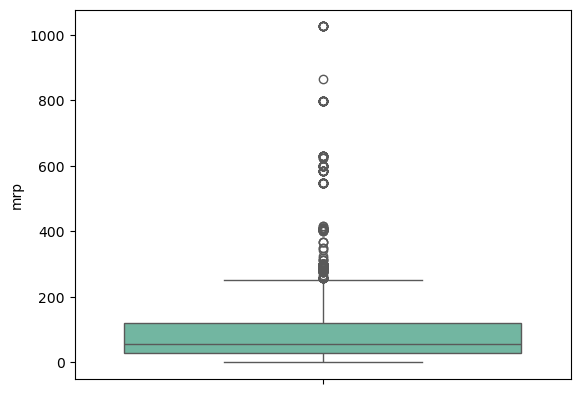

In [29]:
sns.boxplot(df["mrp"],palette="Set2")

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\1107460511.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["mrp"],kde="True")


<Axes: xlabel='mrp', ylabel='Density'>

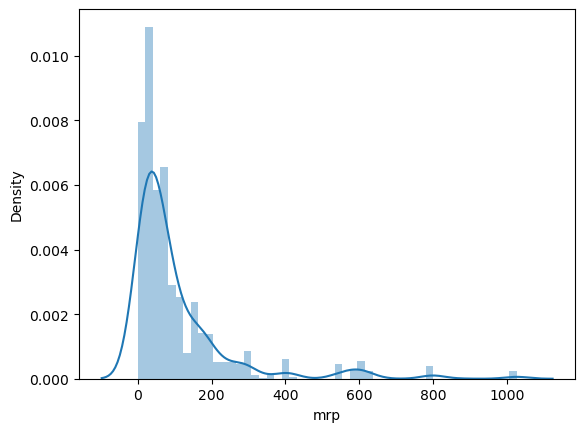

In [261]:
sns.distplot(df["mrp"],kde="True")

In [274]:
lower_sp,upper_sp=outlier(df["selling_price"])
lower_sp,upper_sp

(np.float64(-92.75), np.float64(217.25))

In [276]:
no_of_outler=len(df[(df["selling_price"]<lower_sp) | (df["selling_price"]>upper_sp)])

In [277]:
no_of_outler

197

In [278]:
lower_op,upper_op=outlier(df["offer_percentage"])
lower_op,upper_op

(np.float64(-30.0), np.float64(50.0))

In [279]:
no_of_outler=len(df[(df["offer_percentage"]<lower_sp) | (df["offer_percentage"]>upper_sp)])

In [280]:
no_of_outler

0

In [281]:
lower_dc,upper_dc=outlier(df["Delivery_Charges(Handelling+Delivery)"])
lower_dc,upper_dc

(np.float64(-1.5), np.float64(58.5))

In [282]:
no_of_outler=len(df[(df["Delivery_Charges(Handelling+Delivery)"]<lower_sp) | (df["Delivery_Charges(Handelling+Delivery)"]>upper_sp)])

In [283]:
no_of_outler

0

# Data Vizualization

In [4]:
df=pd.read_csv("./main_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2098 entries, 0 to 2097
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   name                                   2098 non-null   object        
 1   Category                               2098 non-null   object        
 2   mrp                                    2098 non-null   int64         
 3   selling_price                          2098 non-null   float64       
 4   offer_percentage                       2098 non-null   int64         
 5   delivery_time(MIN)                     2098 non-null   int64         
 6   quantity                               2098 non-null   object        
 7   scrape_date                            2098 non-null   datetime64[ns]
 8   scrape_time                            2098 non-null   object        
 9   location                               2098 non-null   object  

# Univariate 

In [304]:
print(df['Platform'].value_counts())
x,y=df['Platform'].value_counts().values
x,y

Platform
Blinkit      1145
BigBasket     960
Name: count, dtype: int64


(np.int64(1145), np.int64(960))

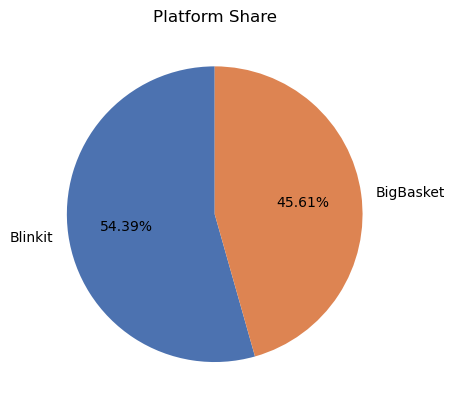

In [305]:
plat_counts = df['Platform'].value_counts()
plt.pie(plat_counts.values, labels=plat_counts.index, autopct='%1.2f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Platform Share')
plt.show()

## from the scrapped data blinkt share is 54.39 percent and bigbasket share is 45.61 percent

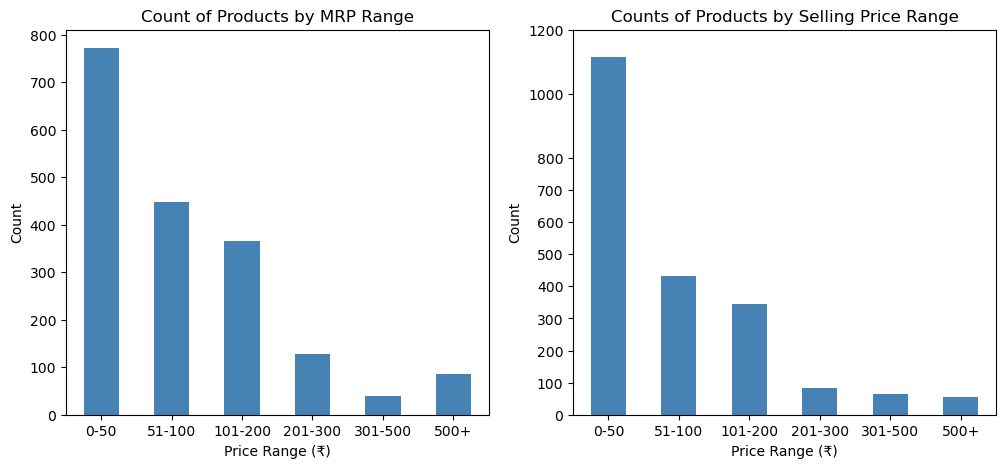

In [76]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
bins = [0, 50, 100, 200, 300, 500, 1000]
labels = ['0-50', '51-100', '101-200', '201-300', '301-500', '500+']
df['mrp_range'] = pd.cut(df['mrp'], bins=bins, labels=labels)
df['mrp_range'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Count of Products by MRP Range')
plt.xlabel('Price Range (₹)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.subplot(1,2,2)
bins = [0, 50, 100, 200, 300, 500, 1100]
labels = ['0-50', '51-100', '101-200', '201-300', '301-500', '500+']
df['sp_range'] = pd.cut(df['selling_price'], bins=bins, labels=labels, include_lowest=True)
df['sp_range'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Counts of Products by Selling Price Range')
plt.xlabel('Price Range (₹)')
plt.ylabel('Count')
plt.yticks([0,100,200,300,400,500,600,700,800,1000,1200])
plt.xticks(rotation=0)
plt.show()

### From plot 1 we can observe that 0-50 range price products count is nearly 800.
### From plot 2 0-50 range price products count has increse to above 1000 after applying dicount.
### Others remains same.

In [322]:
print(df['sp_range'].value_counts())
print(df['sp_range'].value_counts().index)
print(df['sp_range'].value_counts().values)

sp_range
0-50       864
51-100     440
101-200    345
201-300     84
301-500     65
500+        56
Name: count, dtype: int64

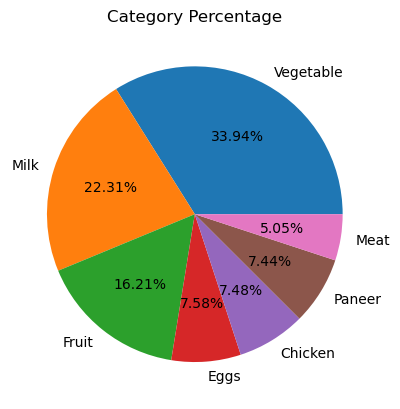

In [439]:
cat_coun=df["Category"].value_counts()
plt.pie(cat_coun.values,labels=cat_coun.index,autopct="%1.2f%%",explode=[0,0,0,0,0,0,0])
plt.title("Category Percentage")
plt.show()


### Vegetable has highest share among all categories with 33.94%
### Meat has the lowest share at 5.05% 

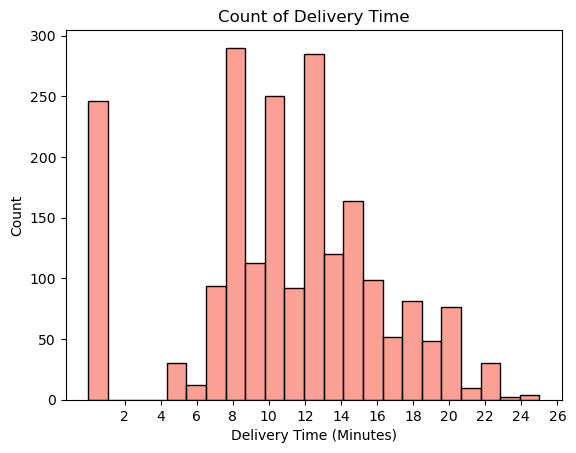

In [473]:
sns.histplot(df["delivery_time(MIN)"],color="salmon")
# sns.color_palette("Set2") 
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Count')
plt.title('Count of Delivery Time')
plt.xticks([2,4,6,8,10,12,14,16,18,20,22,24,26])
plt.show()

### 0 mins indicates product is out of stock
### Minimum Delivery time is 5 Mins and maximum delivery time is 25 mins
### Most deliveries happen  between 8 to 13 minutes

In [426]:
df["Category"].unique()

array(['Paneer', 'Milk', 'Chicken', 'Vegetable', 'Meat', 'Eggs', 'Fruit'],
      dtype=object)

In [429]:
df.columns

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time(MIN)', 'quantity', 'scrape_date', 'scrape_time',
       'location', 'Delivery_Charges(Handelling+Delivery)', 'Period',
       'Climate', 'Surge_charges', 'Platform', 'mrp_range', 'sp_range'],
      dtype='object')

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\2461788240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Climate"].str.upper(),palette=("Set2"))


<Axes: xlabel='count', ylabel='Climate'>

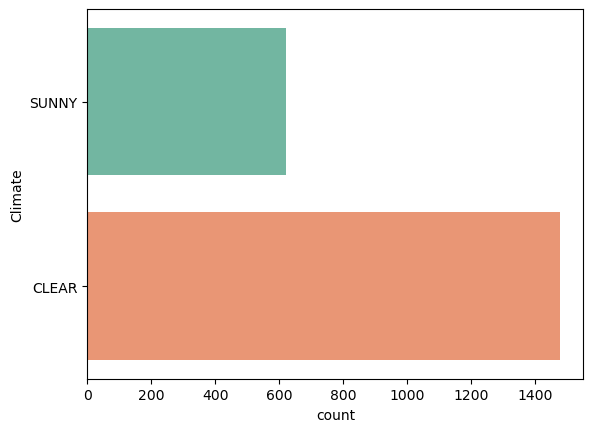

In [457]:
# df["Climate"].upper()
color=sns.color_palette("Set2")
sns.countplot(df["Climate"].str.upper(),palette=("Set2"))

#### In all 4 days most of time, CLEAR climate is present.

In [446]:
df.columns

Index(['name', 'Category', 'mrp', 'selling_price', 'offer_percentage',
       'delivery_time(MIN)', 'quantity', 'scrape_date', 'scrape_time',
       'location', 'Delivery_Charges(Handelling+Delivery)', 'Period',
       'Climate', 'Surge_charges', 'Platform', 'mrp_range', 'sp_range'],
      dtype='object')

In [490]:
df["Stock"].value_counts()

Stock
True     1847
False     251
Name: count, dtype: int64

C:\Users\veera\AppData\Local\Temp\ipykernel_35188\1211702624.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Stock"], palette='Set2')


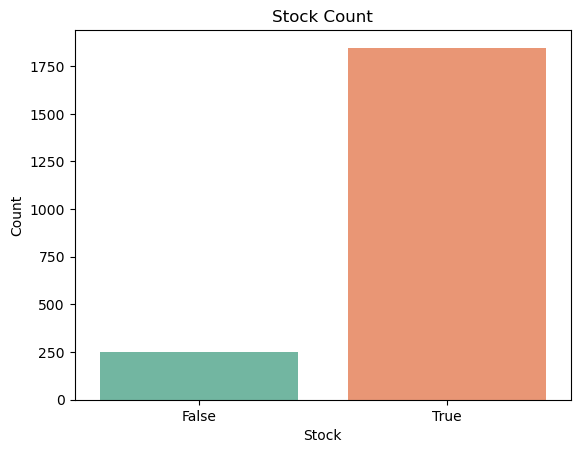

In [496]:
sns.countplot(x=df["Stock"], palette='Set2')
plt.title('Stock Count')
plt.xlabel('Stock')
plt.ylabel('Count')
plt.show()

#### In all 4 days, most of the time Stock is availabe.

# Bivariate

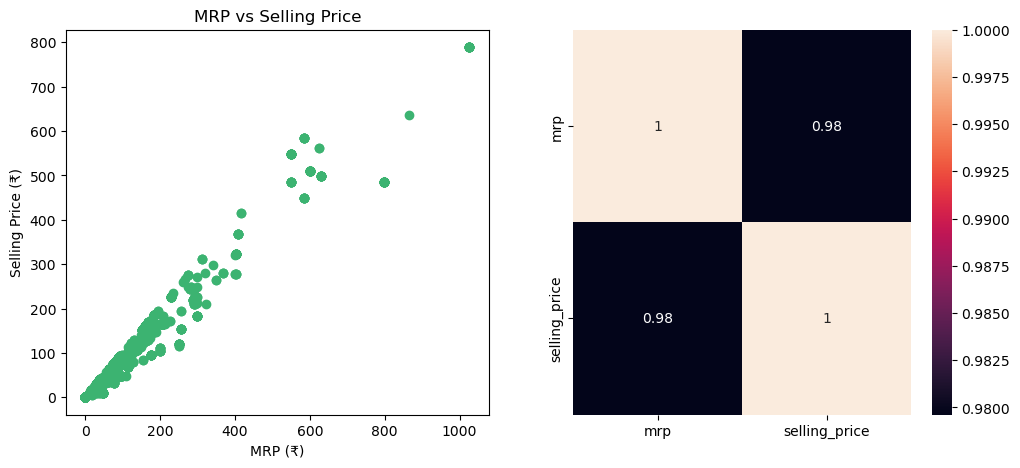

In [53]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(df['mrp'], df['selling_price'],color='mediumseagreen')
plt.title('MRP vs Selling Price')
plt.xlabel('MRP (₹)')
plt.ylabel('Selling Price (₹)')

plt.subplot(1,2,2)
sns.heatmap(df[["mrp",'selling_price']].corr(),annot=True)
plt.show()

# There is a positive relationship — as MRP increases selling price also increases
# The relation is strong with 98% correlation
# Majority of products are clustered below ₹200 MRP — confirming most items are daily budget essentials

In [54]:
# sns.heatmap(df[["mrp",'selling_price']].corr(),annot=True) 

In [21]:
df[["mrp",'selling_price']].corr()

,mrp,selling_price
mrp,1.000000,0.979612
selling_price,0.979612,1.000000


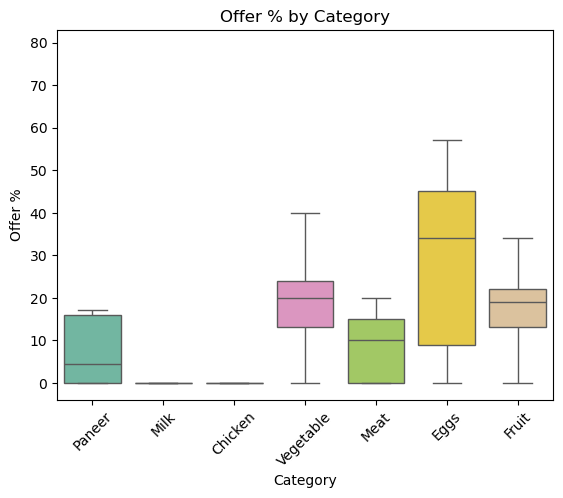

In [70]:
sns.boxplot(x='Category', y='offer_percentage', data=df, 
            palette='Set2', flierprops=dict(marker=''))
plt.title('Offer % by Category')
plt.xlabel('Category')
plt.ylabel('Offer %')
plt.xticks(rotation=45)
plt.show()

# Offer percentage of Milk and Chicken is almost zero — no discounts are applied on these categories
# Average offer percentage of Paneer is around 5% — very low discounts
# Average offer percentage of Meat is around 15% — moderate discounts
# Vegetable has an average offer of around 20% with range going up to 40%
# Fruit offer percentage ranges between 15% to 25% consistently
# Eggs have the highest and most varied offer percentage with average around 35% and range going up to 57% — platforms heavily discount eggs to attract customers


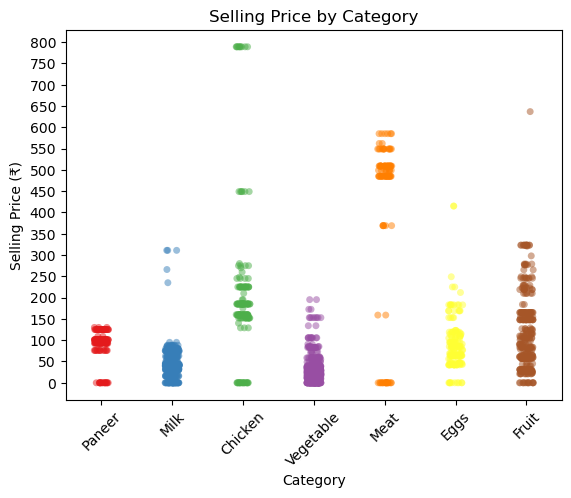

In [11]:
sns.stripplot(x='Category', y='selling_price', data=df, 
              palette='Set1', alpha=0.5, jitter=True)
plt.title('Selling Price by Category')
plt.xlabel('Category')
plt.ylabel('Selling Price (₹)')
plt.xticks(rotation=45)
plt.yticks([0,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800])
plt.show()

# Points at ₹0 represent out of stock items with no selling price recorded
# Paneer selling price falls between ₹80 to ₹150
# Milk selling price mostly falls between ₹10 to ₹100, with a few premium variants between ₹250 to ₹350
# Chicken selling price ranges between ₹150 to ₹350, with some premium cuts at ₹450 and one outlier near ₹800
# Vegetable selling price is mostly between ₹10 to ₹200, with some items between ₹200 to ₹250
# Meat selling price is on the higher side, ranging between ₹500 to ₹650
# Eggs selling price falls between ₹50 to ₹150
# Fruits selling price ranges between ₹50 to ₹350, with one premium item near ₹650

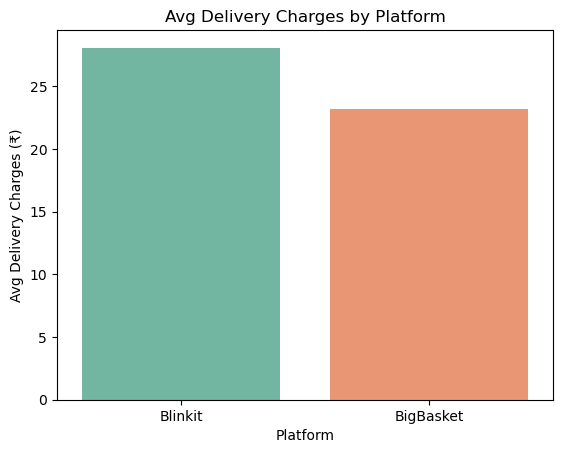

In [79]:
sns.barplot(x='Platform', y='Delivery_Charges(Handelling+Delivery)', 
            data=df, palette='Set2', errorbar=None)
plt.title('Avg Delivery Charges by Platform')
plt.xlabel('Platform')
plt.ylabel('Avg Delivery Charges (₹)')
plt.show()

## insights 
### Average delivery charges for Blinkit is around ₹28 slightly higher than BigBasket
#### Average delivery charges for BigBasket is around ₹23 more affordable for customers
##### Even though BigBasket applies late night delivery fees in some time slots, its overall average delivery charges are still lower than Blinkit  

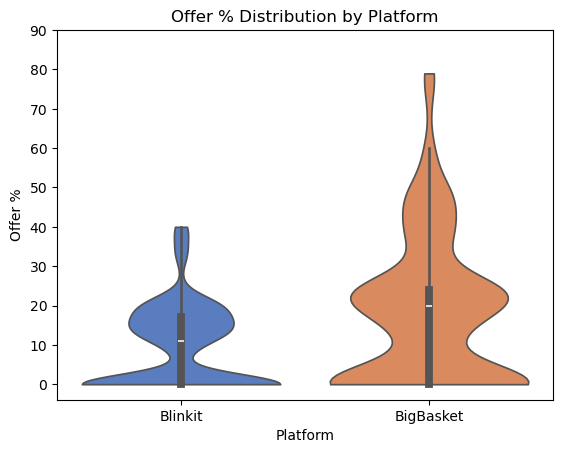

In [57]:
sns.violinplot(x='Platform', y='offer_percentage', 
               data=df, palette='muted',cut=0)
plt.title('Offer % Distribution by Platform')
plt.xlabel('Platform')
plt.yticks([0,10,20,30,40,50,60,70,80,90])
plt.ylabel('Offer %')
plt.show()
# t uses KDE (Kernel Density Estimation) to draw the shape.
# KDE is a smoothing technique that sometimes extends slightly beyond the actual data range to make the curve look smooth.

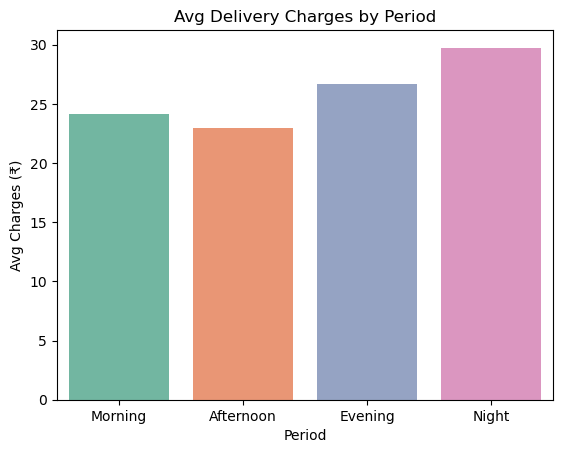

In [28]:
period_order = ['Morning', 'Afternoon', 'Evening', 'Night']
sns.barplot(x='Period', y='Delivery_Charges(Handelling+Delivery)', 
            data=df, order=period_order, palette='Set2', errorbar=None)
plt.title('Avg Delivery Charges by Period')
plt.xlabel('Period')
plt.ylabel('Avg Delivery Charges (₹)')
plt.show()

#### Average delivery charges are lowest in Afternoon at ₹23. Best time to order for cheaper delivery
#### Morning charges are ₹24. slightly higher than afternoon
#### Evening charges rise to ₹27. demand increases during evening hours
#### Night has the highest delivery charges at ₹29
#### There is a clear pattern. Delivery charges increase from afternoon to night

## Multivariate

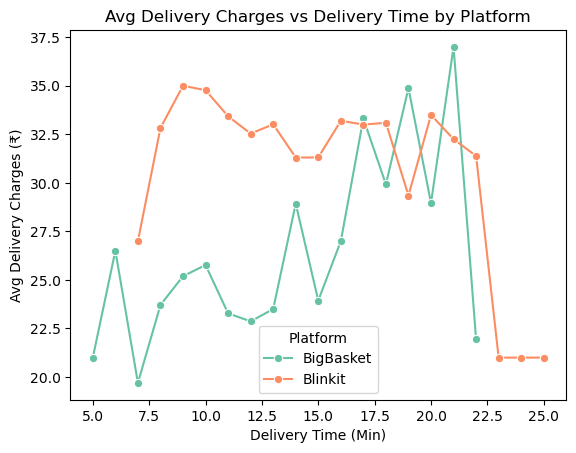

In [59]:
filtered_df = df[df['delivery_time(MIN)'] > 0]
avg = filtered_df.groupby(['Platform', 'delivery_time(MIN)'])['Delivery_Charges(Handelling+Delivery)'].mean().reset_index()
sns.lineplot(x='delivery_time(MIN)', y='Delivery_Charges(Handelling+Delivery)', 
             hue='Platform', data=avg, marker='o', palette='Set2')
plt.title('Avg Delivery Charges vs Delivery Time by Platform')
plt.xlabel('Delivery Time (Min)')
plt.ylabel('Avg Delivery Charges (₹)')
plt.legend(title='Platform')
plt.show()

## insights 
### Blinkit starts at around ₹27 for 5 minute delivery and BigBasket starts at around ₹21 for 5 minute delivery
### For delivery time between 10 to 15 minutes, Blinkit average charges are around ₹30 to ₹35 and BigBasket is around ₹23 to ₹26
### For delivery time between 20 to 25 minutes, both platforms show fluctuating 
### Maximum delivery time for Blinkit is around 25 minutes and for BigBasket is around 21 minutes
### For delivery time between 7 to 10 minutes, Blinkit and bigbasket charges gradually increase and then slightly decrease after 10 minutes

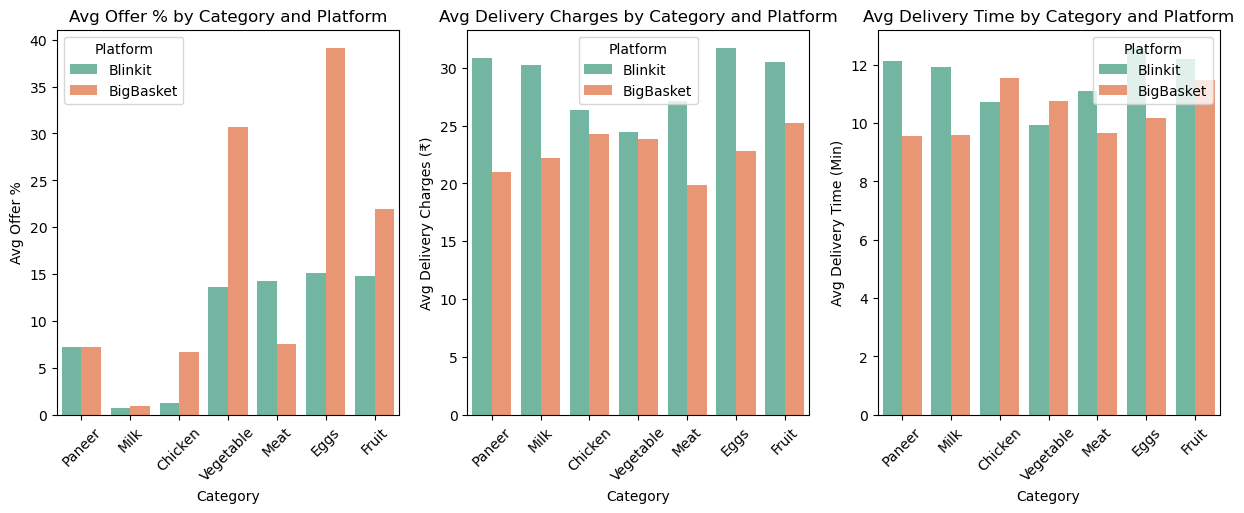

In [80]:
plt.figure(figsize=(15,5)) 
plt.subplot(1,3,1)
sns.barplot(x='Category', y='offer_percentage', 
            hue='Platform', data=df, palette='Set2',errorbar=None)
plt.title('Avg Offer % by Category and Platform')
plt.xlabel('Category')
plt.ylabel('Avg Offer %')
plt.xticks(rotation=45)
plt.legend(title='Platform')
plt.subplot(1,3,2)
sns.barplot(x='Category', y='Delivery_Charges(Handelling+Delivery)', 
            hue='Platform', data=df, palette='Set2', errorbar=None)
plt.title('Avg Delivery Charges by Category and Platform')
plt.xlabel('Category')
plt.ylabel('Avg Delivery Charges (₹)')
plt.xticks(rotation=45)
plt.legend(title='Platform')
plt.subplot(1,3,3)
sns.barplot(x='Category', y='delivery_time(MIN)', hue='Platform',
            data=df, palette='Set2', errorbar=None)
plt.title('Avg Delivery Time by Category and Platform')
plt.xlabel('Category')
plt.ylabel('Avg Delivery Time (Min)')
plt.xticks(rotation=45)
plt.legend(title='Platform')

plt.show()

### Paneer average offer percentage is 7% in both Blinkit and BigBasket
### Milk avg offer percentage is 1% in Blinkit and 2% in BigBasket
### Chicken avg offer percentage is 2% in Blinkit and 7% in BigBasket
#### Vegetable avg offer percentage is 14% in Blinkit and 31% in BigBasket
#### Meat avg offer percentage is 15% in Blinkit and 8% in BigBasket — Blinkit gives better deals on meat
#### Eggs avg offer percentage is 15% in Blinkit and 39% in BigBasket
#### Fruit avg offer percentage is 15% in Blinkit and 22% in BigBasket 
#### overall bigbasket is higher average offer percent compared to blinkit

 
#### Paneer avg delivery charges is ₹31 in Blinkit and ₹21 in BigBasket
#### Milk avg delivery charges is ₹30 in Blinkit and ₹22 in BigBasket
#### Chicken avg delivery charges is ₹26 in Blinkit and ₹24 in BigBasket 
#### Vegetable avg delivery charges is ₹27 in Blinkit and ₹24 in BigBasket
#### Meat avg delivery charges is ₹27 in Blinkit and ₹20 in BigBasket 
#### Eggs avg delivery charges is ₹32 in Blinkit and ₹23 in BigBasket
#### Fruit avg delivery charges is ₹30 in Blinkit and ₹25 in BigBasket
#### Overall Blinkit has higher delivery charges than BigBasket across all categories


#### Paneer avg delivery time is 12 mins in Blinkit and 9.5 mins in BigBasket
#### Milk avg delivery time is 12 mins in Blinkit and 9.5 mins in BigBasket
#### Chicken avg delivery time is 11 mins in Blinkit and 11.5 mins in BigBasket
#### Vegetable avg delivery time is 10 mins in Blinkit and 11 mins in BigBasket
#### Meat avg delivery time is 11 mins in Blinkit and 9.5 mins in BigBasket
#### Eggs avg delivery time is 11 mins in Blinkit and 10 mins in BigBasket
#### Fruit avg delivery time is 11 mins in Blinkit and 11.5 mins in BigBasket
#### Overall Blinkit takes slightly more time for most categories

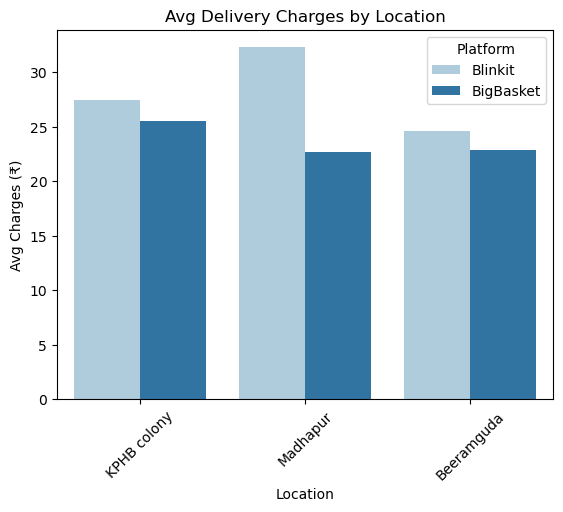

In [66]:
filtered_df = df[~df['location'].isin(['Kondapur', 'Gachibowli'])]
sns.barplot(x='location', y='Delivery_Charges(Handelling+Delivery)',hue="Platform", 
            data=filtered_df, palette='Paired', errorbar=None)
plt.title('Avg Delivery Charges by Location')
plt.xlabel('Location')
plt.ylabel('Avg Charges (₹)')
plt.xticks(rotation=45)
plt.show()

### In KPHB Colony, Blinkit charges around ₹27 and BigBasket charges around ₹25 
### In Madhapur, Blinkit has the highest charges at ₹32 while BigBasket is only ₹23
### In Beeramguda, both platforms have similar charges around ₹24 to ₹23 

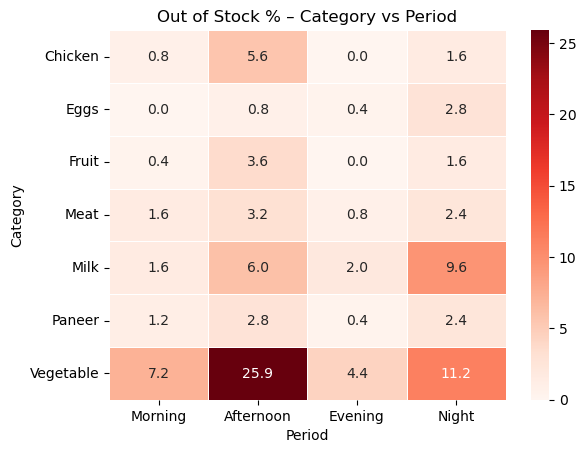

In [31]:
df['Period'] = df['Period'].str.strip().replace({'AfterNoon': 'Afternoon', 'Night/Mid Night': 'Night'})
df['out_of_stock'] = ~df['Stock'].astype(bool)

# Out of stock pivot
pivot = df.pivot_table(index='Category', columns='Period',
                        values='out_of_stock', aggfunc='sum')
pivot = pivot[['Morning', 'Afternoon', 'Evening', 'Night']]

# Convert to percentage of total
pivot_pct = (pivot.div(pivot.sum().sum()) * 100).round(1)

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, linecolor='white', cbar=True)
plt.title('Out of Stock % – Category vs Period')
plt.xlabel('Period')
plt.ylabel('Category')
plt.show()

### Vegetable has the highest out of stock count across all periods
### Paneer has highest out of stock at afternoon with count 7 
### Milk goes out of stock most at Night with 24 counts highest night demand among all categories
### Meat shows consistent out of stock across all periods
### Fruit goes out of stock mostly in Afternoon with 9 counts and 0 in Evening
### Eggs are out of stock at Night with count 7
### Chicken goes out of stock heavily in Afternoon with 14 counts restocks in evening